In [4]:
import re

with open("Kiswahili.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

# Split into sentences on period, exclamation, question mark, or newline
swahili_sentences = re.split(r'[.!?\n]+', raw_text)

# Clean up: remove empty strings and strip whitespace
swahili_sentences = [s.strip() for s in swahili_sentences if len(s.strip()) > 5]

print(f"Total Swahili sentences extracted: {len(swahili_sentences)}")
print(swahili_sentences[:5])

Total Swahili sentences extracted: 41968
['taarifa hiyo ilisema kuwa ongezeko la joto la maji juu ya wastani katikati ya bahari ya UNK inaashiria kuwepo kwa mvua za el nino UNK hadi mwishoni mwa april ishirini moja sifuri imeelezwa kuwa ongezeko la joto magharibi mwa bahari ya hindi linatarajiwa kuhamia katikati ya bahari hiyo hali ambayo itasababisha pepo kutoka kaskazini mashariki kuvuma kuelekea bahari ya hindi', 'aidha ilisema kuwa mwelekeo wa kupungua kwa joto kusini mashariki mwa bahari ya atlantic UNK kusababisha pepo kutoka magharibi kuvuma kuelekea magharibi mwa tanzania katika maeneo ya ziwa victoria', 'mwelekeo wa mvua wa septemba hadi desemba ishirini sifuri tisa unatarajiwa kuwa katika namna tofauti ambapo baadhi ya maeneo yanaweza kunufaika huku mengine UNK', 'ilifafanua kuwa msimu wa vuli UNK maeneo ambayo hupata mvua mara mbili ambayo ni kaskazini mwa nchi ikiwa ni nyanda za juu kaskazini mashariki kanda ya ziwa victoria na pwani ya kaskazini', 'katika maeneo hayo mvua 

In [5]:
!pip install langdetect -q

import pandas as pd
from langdetect import detect

netflix_df = pd.read_csv("netflix_reviews.csv")
print(netflix_df.head())
print(netflix_df.columns.tolist())  # so you can see which column has the review text

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
                               reviewId               userName  \
0  25dd54e7-6414-4513-bbd0-1faa2b8dda94            Sanju Singh   
1  4840822e-3630-48d9-95a1-31a49ac69cd6  Aniruddha Kumar Gupta   
2  10936073-75d2-400b-8109-e32185c2aca9           Shiv Shankar   
3  280357fa-b0f5-461c-9f8f-2e2a508350d2           Shobha Singh   
4  f91a2b43-e8d6-45dd-99c2-6b97e47fe141   Deborah Scheipsmeier   

                                             content  score  thumbsUpCount  \
0  Netflix is a great streaming platform with the...      5              0   
1                                     very worst app      1              0   
2                naadaniyan type movie in Netflix 🤮🤮      1              0   
3                 This app is good but it's not free      3              0   
4                                       Great movies      5              0   

    reviewCr

In [6]:
def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except:
        return False

netflix_df["is_english"] = netflix_df["content"].apply(is_english)

english_df = netflix_df[netflix_df["is_english"] == True][["content"]].copy()
english_df.columns = ["text"]
english_df["language"] = "English"

print(f"English rows kept: {len(english_df)}")
print(english_df.head())

English rows kept: 123594
                                                text language
0  Netflix is a great streaming platform with the...  English
1                                     very worst app  English
3                 This app is good but it's not free  English
4                                       Great movies  English
5                          it's a God app for movies  English


In [7]:
swahili_df = pd.DataFrame({
    "text": swahili_sentences,
    "language": "Swahili"
})

print(swahili_df.head())

                                                text language
0  taarifa hiyo ilisema kuwa ongezeko la joto la ...  Swahili
1  aidha ilisema kuwa mwelekeo wa kupungua kwa jo...  Swahili
2  mwelekeo wa mvua wa septemba hadi desemba ishi...  Swahili
3  ilifafanua kuwa msimu wa vuli UNK maeneo ambay...  Swahili
4  katika maeneo hayo mvua zinatarajiwa kunyesha ...  Swahili


In [8]:
# Sample English rows to match Swahili count
english_sampled = english_df.sample(n=len(swahili_df), random_state=42).reset_index(drop=True)

# Combine
df = pd.concat([swahili_df, english_sampled], ignore_index=True)
df = df.dropna()
df = df[df["text"].str.strip() != ""]

print("Final dataset shape:", df.shape)
print("\nLanguage distribution:")
print(df["language"].value_counts())

Final dataset shape: (83936, 2)

Language distribution:
language
Swahili    41968
English    41968
Name: count, dtype: int64


In [9]:
df.to_csv("dataset.csv", index=False)
print("Dataset saved!")

Dataset saved!


In [10]:
import re
import string

def preprocess(text):
    text = str(text).lower()                          # lowercasing
    text = re.sub(r'\d+', '', text)                   # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra spaces
    return text

df["clean_text"] = df["text"].apply(preprocess)

print("Preprocessing done!")
print(df[["text", "clean_text"]].head(10))

Preprocessing done!
                                                text  \
0  taarifa hiyo ilisema kuwa ongezeko la joto la ...   
1  aidha ilisema kuwa mwelekeo wa kupungua kwa jo...   
2  mwelekeo wa mvua wa septemba hadi desemba ishi...   
3  ilifafanua kuwa msimu wa vuli UNK maeneo ambay...   
4  katika maeneo hayo mvua zinatarajiwa kunyesha ...   
5  mvua za msimu ambazo UNK mara moja kwa mwaka z...   
6  katika mikoa ya kati mvua zinatarajiwa kunyesh...   
7  mikoa ya nyanda za juu magharibi mvua UNK kuan...   
8  katika mikoa ya kusini na pwani ya kusini amba...   
9  taarifa hiyo ilieleza kuwa baadhi ya maeneo ya...   

                                          clean_text  
0  taarifa hiyo ilisema kuwa ongezeko la joto la ...  
1  aidha ilisema kuwa mwelekeo wa kupungua kwa jo...  
2  mwelekeo wa mvua wa septemba hadi desemba ishi...  
3  ilifafanua kuwa msimu wa vuli unk maeneo ambay...  
4  katika maeneo hayo mvua zinatarajiwa kunyesha ...  
5  mvua za msimu ambazo unk mara 

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4))
X = vectorizer.fit_transform(df["clean_text"])
y = df["language"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Feature extraction done!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Feature extraction done!
Training samples: 67148
Test samples:     16788


In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Both models trained!")

Both models trained!



========== Naive Bayes ==========
Accuracy: 0.9985
              precision    recall  f1-score   support

     English       1.00      1.00      1.00      8394
     Swahili       1.00      1.00      1.00      8394

    accuracy                           1.00     16788
   macro avg       1.00      1.00      1.00     16788
weighted avg       1.00      1.00      1.00     16788



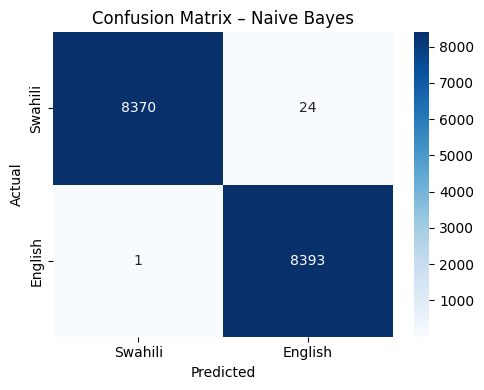


========== Logistic Regression ==========
Accuracy: 0.9995
              precision    recall  f1-score   support

     English       1.00      1.00      1.00      8394
     Swahili       1.00      1.00      1.00      8394

    accuracy                           1.00     16788
   macro avg       1.00      1.00      1.00     16788
weighted avg       1.00      1.00      1.00     16788



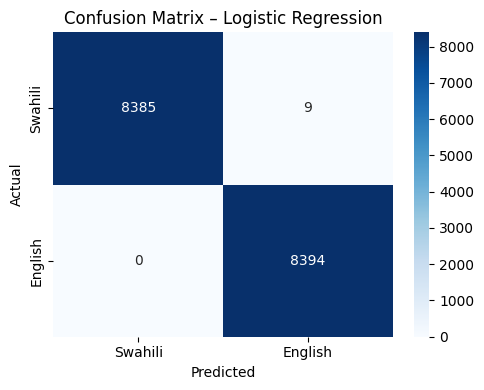

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in [("Naive Bayes", nb_model), ("Logistic Regression", lr_model)]:
    y_pred = model.predict(X_test)
    print(f"\n========== {name} ==========")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=["Swahili", "English"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=["Swahili", "English"],
                yticklabels=["Swahili", "English"],
                cmap="Blues")
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [14]:
import pickle

# Save model and vectorizer
with open("language_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved!")

Model and vectorizer saved!


In [ ]:
!pip install streamlit pyngrok -q

In [15]:
app_code = """
import streamlit as st
import pickle, re, string

with open("language_model.pkl", "rb") as f:
    model = pickle.load(f)
with open("vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'\\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return re.sub(r'\\s+', ' ', text).strip()

def detect_code_mixing(text):
    tokens = text.split()
    token_labels = []
    for token in tokens:
        cleaned = preprocess(token)
        if not cleaned:
            continue
        features = vectorizer.transform([cleaned])
        lang = model.predict(features)[0]
        token_labels.append((token, lang))

    if not token_labels:
        return None

    langs = [l for _, l in token_labels]
    en_ratio = langs.count("English") / len(langs)
    sw_ratio = langs.count("Swahili") / len(langs)

    if en_ratio > 0.15 and sw_ratio > 0.15:
        label = "Code-Mixed (English + Swahili)"
    elif en_ratio >= sw_ratio:
        label = "English"
    else:
        label = "Swahili"

    return label, en_ratio, sw_ratio, token_labels

st.set_page_config(page_title="Language ID + Code-Mixing", page_icon="🌍")
st.title("🌍 Language Identification with Code-Mixing Detection")

user_input = st.text_area("Enter text:", height=150,
    placeholder="Try: 'Ninaenda to the market kila siku'")

if st.button("Detect"):
    if not user_input.strip():
        st.warning("Please enter some text.")
    else:
        result = detect_code_mixing(user_input)
        if result:
            label, en_ratio, sw_ratio, token_labels = result
            st.success(f"Detected: **{label}**")
            st.progress(en_ratio, text=f"English: {en_ratio:.0%}")
            st.progress(sw_ratio, text=f"Swahili: {sw_ratio:.0%}")

            st.markdown("#### Word-by-word breakdown")
            cols = st.columns(4)
            for i, (word, lang) in enumerate(token_labels):
                flag = "🇬🇧" if lang == "English" else "🇰🇪"
                cols[i % 4].markdown(f"**{word}** {flag}")

st.markdown("---")
st.caption("CSC423 NLP Term Project")
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py written!")

app.py written!


In [16]:
from google.colab import files
files.download("language_model.pkl")
files.download("vectorizer.pkl")
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>